In [1]:

from scipy.integrate import odeint
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib.animation import FuncAnimation
import sys

#import jax.numpy as jnp

In [2]:
#set up grid
nx,ny = 200,200
x = np.linspace(0, nx, nx + 1)
y = np.linspace(0, ny, ny + 1)
X, Y = np.meshgrid(x, y)
L = 1
delta = L/nx


#charge density
rho = np.zeros([nx+1,ny+1],float)
rho[40:60,:] = -1e12* (1.6e-19) #C/m^2
epsilon = 8.85e-12 #F/m

#time steps
steps = 10
dt = 1e-8

#magnetic field
B = 0.1 #Tesla

In [ ]:
# trial 2: including periodic side boundary
# https://my.ece.utah.edu/~ece6340/LECTURES/Feb1/Nagel%202012%20-%20Solving%20the%20Generalized%20Poisson%20Equation%20using%20FDM.pdf
# Matrix inversion method: instantaneous Poisson's solver
def create_A(nx, ny):
    num_diag = (nx+1)*(ny-1)
    diag = np.full(num_diag, -4)
    lower = np.full((num_diag-1),1)
    upper = np.full((num_diag-1),1)
    identity = np.full(num_diag-(nx-1),1)
    side = np.full(ny-1,1)

    lower[nx-2::nx-1] = 0
    upper[nx-2::nx-1] = 0


    diagonal = [diag,lower,upper,identity,identity,side,side]
    offsets = [0,-1,1,-(nx-1),(nx-1),-nx*(ny-1),nx*(ny-1)]

    return diags(diagonal, offsets, shape =(num_diag, num_diag), format= 'csr')

#construct boundary vector B
def create_B(rho):
    lil_B2 = np.zeros(((nx+1)*(ny-1),1),float)
    f = rho[1:nx,0:ny+1].reshape((nx+1)*(ny-1),1,order = 'F')*delta**2*(-1)/epsilon

    lil_B2[0:(nx+1)*(ny-1):(ny-1)] = -rho[0,0:nx+1].reshape((ny+1),1)
    lil_B2[ny-2:(nx+1)*(ny-1):(ny-1)] = -rho[ny,0:nx+1].reshape(ny+1,1)

    return f


def solve_poisson_1(rho):
    phi = np.zeros([nx+1,ny+1],float)
    A = create_A(nx,ny)
    B = create_B(rho)
    phi_flat = phi.flatten(order= 'F') 
    phi_flat= spsolve(A,B)
    phi[1:nx,0:ny+1] = phi_flat.reshape(nx-1,ny+1,order = 'F')
    return phi

In [ ]:
def electric_field(phi):
    Ex = np.zeros([nx+1, ny+1], float)
    Ey = np.zeros([nx+1, ny+1], float)

    for i in range(1, nx):
        for j in range(1, ny):
            #Gemini pointed out how 2D-array indexing works as below:
            #row of an array is 'i' (y-direction)
            #column of an array is 'j' (x-direction)
            Ex[i, j] = -(phi[i, j + 1] - phi[i, j - 1]) / (2*delta)
            Ey[i, j] = -(phi[i + 1, j] - phi[i - 1, j]) / (2*delta)


    plt.show()
    return Ex, Ey

def velocity(Ex, Ey, B):
    vx = np.zeros([nx+1, ny+1], float)
    vy = np.zeros([nx+1, ny+1], float)

    for i in range(1, nx):
        for j in range(1, ny):
            vx[i, j] = Ey[i, j] / B
            vy[i, j] = -Ex[i, j] / B

    return vx, vy

#forward Euler method
def forward_euler_charge_density(rho, vx, vy, dt):
    #rho_new_time = rho.copy()
    for n in range(1):
        rho_new_time = rho.copy()
        for i in range(1, nx):
            for j in range(1, ny):
                # not sure vx and vy should be at i,j or i+1,j or i-1,j
                rho[i, j] = rho[i, j] - dt *( (rho_new_time[i +1, j]  - rho_new_time[i - 1, j] )* vy[i, j] /  (2*delta) +
                                                    (rho_new_time[i, j+1]  - rho_new_time[i, j - 1] ) * vx[i, j]/ (2*delta)  )
                #rho[i, j] = rho_new_time[i, j] - dt *( (rho_new_time[i, j]  - rho_new_time[i - 1, j] )* vy[i, j] /  (1*delta) +
                #                                   (rho_new_time[i, j]  - rho_new_time[i, j - 1] ) * vx[i, j]/ (1*delta)  )
                #rho_new_time[i, j] = rho[i, j] - dt * ( (rho[i , j] * vx[i, j] - rho[i - 1, j] * vx[i - 1, j]) /  delta +
                #                                    (rho[i, j] * vy[i, j] - rho[i, j - 1] * vy[i, j - 1]) / delta )
                rho[0,:] = 0
                rho[nx,:]=0
    return rho

def solve_continuity(rho, vx, vy, dt):
    for n in range (1):
        rho_new = rho.copy()
        for i in range (1,nx):
            for j in range (ny+1):
                #Gemini helped me debug the indexing issue (out of bounds): keep grounding boundaries fixed and updating the sides only by wrapping around
                #Google how negative indexing works in Python
                rho[i,j] = rho_new[i,j] - dt*( (rho_new[i+1,j]-rho_new[i-1,j])*vy[i,j]/(2*delta) + 
                                                   (rho_new[i,(j+1)%(ny+1)]-rho_new[i,(j-1)%(ny+1)])*vx[i,j]/(2*delta) )

        rho[0,:] = 0
        rho[nx,:]=0
    return rho

   


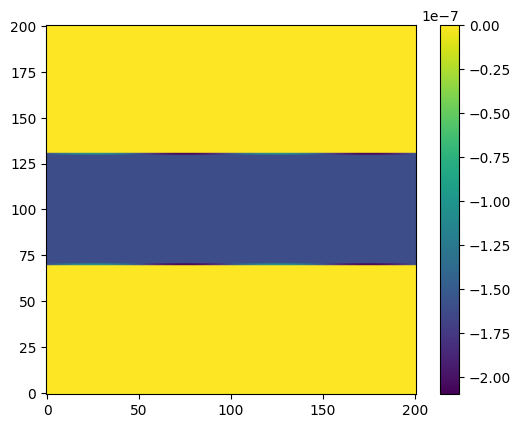

In [ ]:
#initial charge density (Daisy)
#slab of electrons in the middle (conductor top and bottom: grounded)

rho = np.zeros([nx+1,ny+1],float)
rho[70:131,:]= -1e12* (1.6e-19) 

# small surface perturbations to initial charge density
rho[130,:] += 0.5e-7 *np.sin(0.0628*x)
rho[70,:] += 0.5e-7 *np.sin(0.0628*x)


plt.imshow(rho, origin = 'lower')
plt.colorbar()


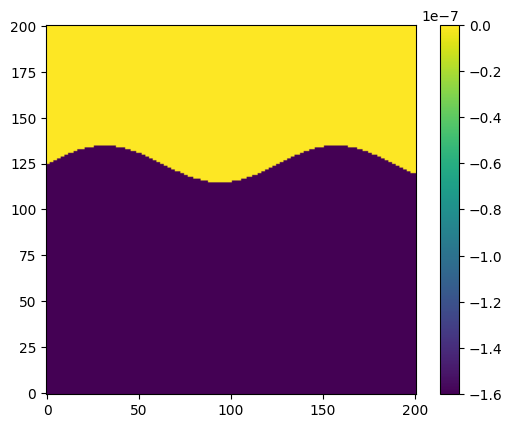

In [6]:
#initial charge density (Subin)
rho = np.zeros([nx+1,ny+1],float)
amplitude = 10
wave_number = 0.05
y_center = nx/2+25   
charge_density = -1e12* (1.6e-19) #C/m^2
#rho[0:110,:] = charge_density
perturbation = y_center + amplitude * np.sin(wave_number *x)

for i in range (nx+1):
    y_value = int(round(perturbation[i]))
    if (y_value>0):
        rho[0:y_value,i] = charge_density


plt.imshow(rho, origin = 'lower')
plt.colorbar()


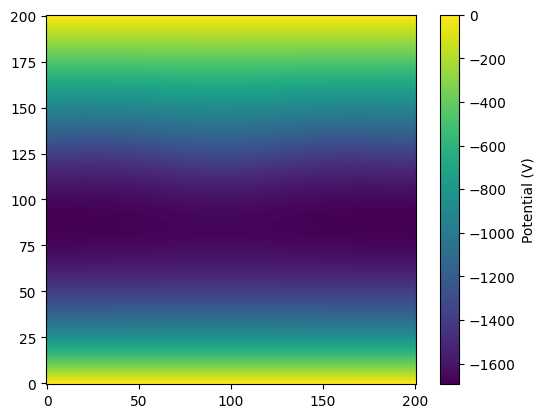

In [7]:
# solve Poisson equation with Matrix Inversion

phi = solve_poisson_1(rho)
plt.imshow(phi, origin = 'lower')
plt.colorbar(label="Potential (V)",shrink=1)
#ax.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
#              density=1.5, arrowstyle='->', arrowsize=1.5)


Ex, Ey = electric_field(phi)
vx, vy = velocity(Ex, Ey, B)
#plt.imshow(solve_rho_ode(vx,vy,rho), origin = 'lower')
np.set_printoptions(threshold=sys.maxsize, linewidth=200) 


In [8]:
# not sure if this is correct
def charge_density_ode(time_span, rho, vx, vy):
    rho= rho.reshape((nx+1, ny+1))
    dndt = np.zeros_like(rho)
    #dndt[0, :] = 0
    #dndt[nx, :] = 0
       
    for i in range(1, nx):
        for j in range(1, ny):
            dndt[i, j] = - ( (rho[i + 1, j]  - rho[i - 1, j] ) * vx[i , j]/ (2 * delta) +
                             (rho[i, j + 1]  - rho[i, j - 1] ) * vy[i, j ]/ (2 * delta) )
    return dndt.flatten()

def solve_rho_ode(vx,vy,rho):
    #vx, vy = velocity(Ex, Ey, B)
    time_span = (0.0, 0.01)
    time_intervals = np.linspace(0.0, 0.01,20)
    rho_0 = rho.flatten()
    sol = solve_ivp(charge_density_ode, time_span, rho_0, method='RK45', t_eval=time_intervals, args=(vx, vy))
    rho_new = sol.y[:,-1]
    return rho_new.reshape(nx+1, ny+1)

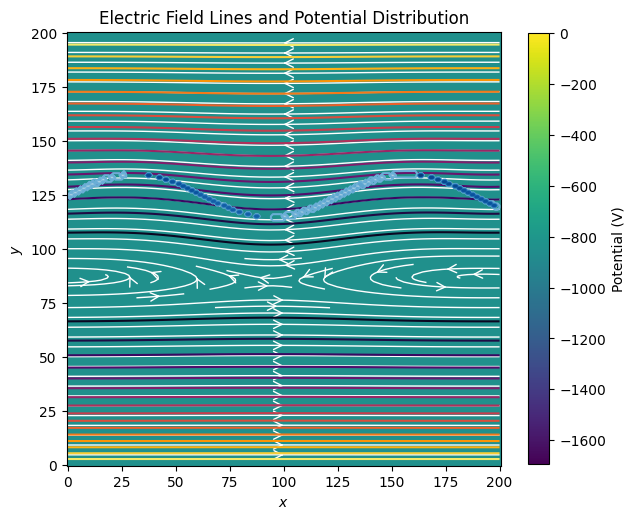

In [ ]:
#https://scipython.com/blog/visualizing-a-vector-field-with-matplotlib/
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title('Electric Field Lines and Potential Distribution')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
dt = 1000

#Google how to plot streamlines using the link above
ax.streamplot(X, Y, vx, vy, color="white", linewidth=1, cmap=plt.cm.inferno,
              density=1.5, arrowstyle='->', arrowsize=1.5)
rho_new = forward_euler_charge_density(rho,vx,vy,dt)
plt.imshow(phi, origin='lower')
plt.colorbar(label="Potential (V)",shrink=0.8)

plt.contour(X, Y, phi, levels=20, cmap='inferno')
plt.contour(X, Y, rho, levels=20, cmap='Blues')
plt.imshow(rho_new, origin = 'lower')
plt.show()

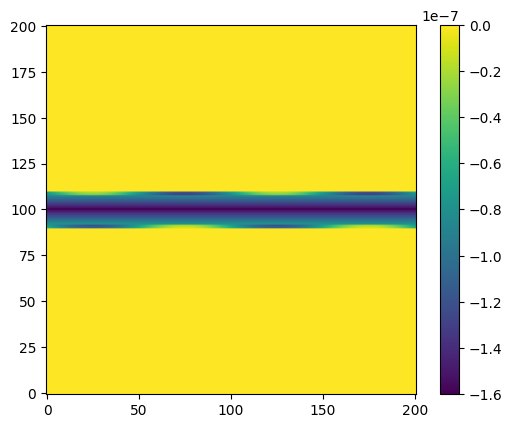

Time step 0
Total charge = -0.0004422000001991651
Time step 500
Total charge = -0.00044220011361276797
Time step 1000
Total charge = -0.00044220030492646474
Time step 1500
Total charge = -0.0004422006482885487
Time step 2000
Total charge = -0.0004422012149460421
Time step 2500
Total charge = -0.0004422020717489377
Time step 3000
Total charge = -0.00044220327983080806
Time step 3500
Total charge = -0.0004422048935177863
Time step 4000
Total charge = -0.000442206959506728
Time step 4500
Total charge = -0.0004422095163401569
Time step 5000
Total charge = -0.0004422125941910862
Time step 5500
Total charge = -0.0004422162149557991
Time step 6000
Total charge = -0.0004422203926379797
Time step 6500
Total charge = -0.0004422251339940307
Time step 7000
Total charge = -0.0004422304393977046
Time step 7500
Total charge = -0.00044223630387295884
Time step 8000
Total charge = -0.0004422427182376752
Time step 8500
Total charge = -0.00044224967029785707
Time step 9000
Total charge = -0.0004422571460

MovieWriter imagemagick unavailable; using Pillow instead.


Simulation saved.
Saving animation... This may take a moment.


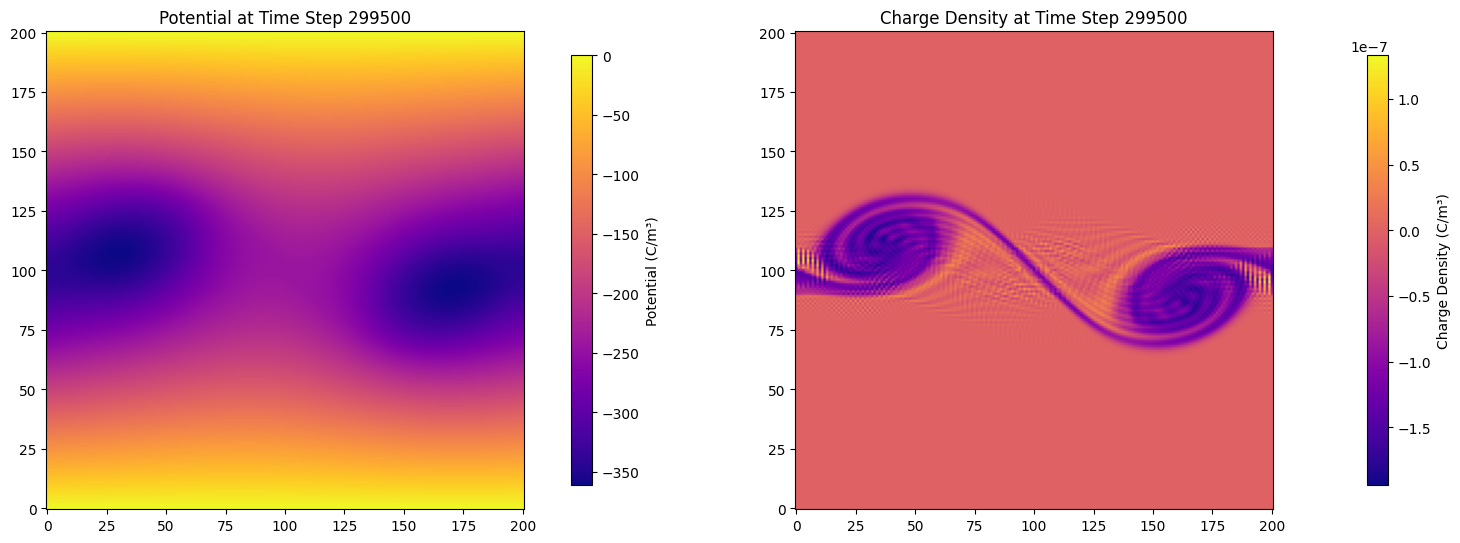

In [ ]:
#run simulation
#set up initial charge density with perturbations
'''
rho = np.zeros([nx+1,ny+1],float)
rho[100,:]= -1e12* (1.6e-19) 
for i in range (101,120):
    for j in range (ny+1):
        rho[i,j] = rho[i-1,j]+5e-9

for i in range (99,79,-1):
    for j in range (ny+1):
        rho[i,j]= rho[i+1,j]+5e-9


rho[118:120,:] += 5e-8 *np.sin(0.0628*x)
rho[80:82,:] += 5e-8 *np.sin(0.0628*x)
'''
rho = np.zeros([nx+1,ny+1],float)
rho[100,:]= -1e12* (1.6e-19) 
for i in range (101,110):
    for j in range (ny+1):
        rho[i,j] = rho[i-1,j]+1e-8

for i in range (99,89,-1):
    for j in range (ny+1):
        rho[i,j]= rho[i+1,j]+1e-8


rho[108:110,:] += 0.5e-7 *np.sin(0.0628*x)
rho[90:92,:] += 0.5e-7 *np.sin(0.0628*x)

'''
rho = np.zeros([nx+1,ny+1],float)
amplitude = 3
wave_number = 0.04
y_center = nx/2+25   
charge_density = 1e12* (1.6e-19) #C/m^2
#rho[0:110,:] = charge_density
perturbation = y_center + amplitude * np.sin(wave_number *x)

for i in range (nx+1):
    y_value = int(round(perturbation[i]))
    if (y_value>0):
        rho[0:y_value,i] = charge_density
'''

dt = 5e-10
history = []
file_save = {}
frame_interval = 500
time_intervals = np.linspace(0, dt, 1)

plt.imshow(rho, origin = 'lower')
plt.colorbar()


step = 300000
for i in range (step):
    
    phi = solve_poisson_1(rho)
    Ex, Ey = electric_field(phi)
    vx, vy = velocity(Ex, Ey, B)
    rho_new = solve_continuity(rho,vx,vy,dt)
    #rho_new = fast_fourier_transform_rho(rho,vx,vy,dt)
    #rho_new = solve_rho_ode(vx,vy,rho)
    '''
    rho_flat = rho.flatten()
    sol = solve_ivp(charge_density_ode, (0,dt), rho_flat, method='RK45', t_eval=time_intervals, args=(vx, vy))
    rho_new_flat = sol.y[:,-1]
    rho = rho_new_flat.reshape(nx+1,ny+1)
    '''
    rho =  rho_new
    #rho = np.sum(rho_new)

    #Google how to save data in Python
    if i % frame_interval == 0:
        print(f"Time step {i}")
        print(f"Total charge = {np.sum(rho)}")
        history.append((rho.copy(), phi.copy(),i))
        file_save[f"time_step_{i}"] = (rho.copy(), phi.copy())
        np.savez('normal_perb_for_thin_slab.npz', **file_save)

print("Simulation saved.")
rho_initial, phi_initial,i = history[0]

fig = plt.figure(figsize=(19, 6))
ax1 = fig.add_subplot(1, 1, 1)
plot_1 = ax1.imshow(rho_initial, origin = 'lower',cmap = 'plasma')
plot_1_tiltle = ax1.set_title(f"Charge Density at Time Step {i}")
fig.colorbar(plot_1, ax=ax1, label='Charge Density (C/m³)', shrink=0.9)
        
ax2 = fig.add_subplot(1, 2, 1)
plot_2 = ax2.imshow(phi_initial, origin = 'lower',cmap = 'plasma')
plot_2_tiltle = ax2.set_title(f"Potential at Time Step {i}")
fig.colorbar(plot_2, ax=ax2, label='Potential (C/m³)', shrink=0.9)
        #ax2.streamplot(X, Y, Ex, Ey, color="white", linewidth=1, cmap=plt.cm.inferno,
         #     density=1.5, arrowstyle='->', arrowsize=1.5)

#plt.show()
plt.tight_layout()

#Google how to animate in Python
def update(frame):
    rho_data, phi_data, step_num = history[frame]
    #scatter.set_offsets(np.vstack((nx, ny)).T)
    plot_1.set_data(rho_data)
    plot_2.set_data(phi_data)
    plot_1.set_clim(np.min(rho_data), np.max(rho_data))
    plot_2.set_clim(np.min(phi_data), np.max(phi_data))
    plot_1_tiltle.set_text((f"Charge Density at Time Step {step_num}"))
    plot_2_tiltle.set_text((f"Potential at Time Step {step_num}"))

    return plot_1, plot_2

ani = FuncAnimation(fig, update, frames=len(history), blit=True, interval=frame_interval)
print("Saving animation... This may take a moment.")
ani.save('draft.gif', writer='imagemagick', fps=15)

plt.show()

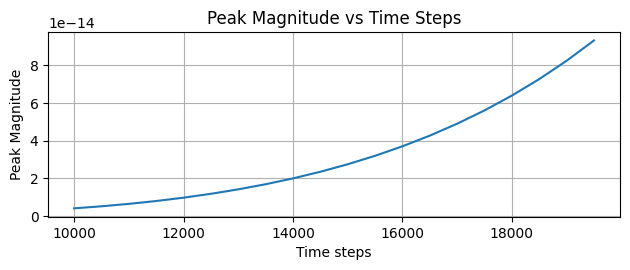

Slope: 0.00032064038508218995, Intercept: -36.12233758178726


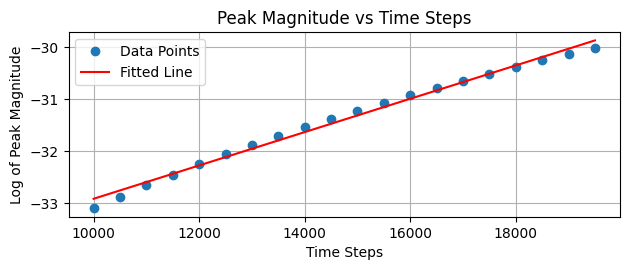

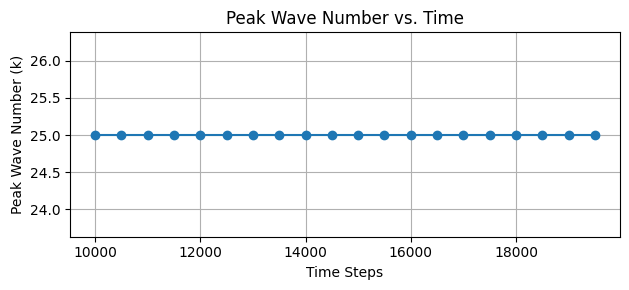

In [ ]:
#data analysis of perturbation growth rate
#https://numpy.org/doc/2.3/reference/generated/numpy.fft.fft.html
def fft_rho_slice(rho_slice):
    N = len(rho_slice)
    rho_fft = np.fft.fft(rho_slice)
    freq = np.fft.fftfreq(N, d=delta)
    magnitude = np.abs(rho_fft)
    wave_number = freq * 2 * np.pi  # Convert frequency to wave number

    return wave_number[:N // 2], magnitude[:N // 2]  # Return only positive frequencies

def find_peaks(rho_slice):
    wave_number, magnitude = fft_rho_slice(rho_slice)
    #positve_k = (wave_number > 10) &  (wave_number < 20)
    positve_k = (wave_number > 10)
    peak_wave_number = np.argmax(magnitude[positve_k])
    #print(f"Peak wave number: {fft_rho_slice(rho_slice)[0][positve_k][peak_wave_number]}")
    #print(f"Peak magnitude: {fft_rho_slice(rho_slice)[1][positve_k][peak_wave_number]}")
    return wave_number[positve_k][peak_wave_number], magnitude[positve_k][peak_wave_number]

list_wave_number = []
list_magnitude = []
list_time_steps = []
frame_interval = 500
#dt = 5e-15
load_data = np.load("long_run_1000000steps_25_slab.npz", allow_pickle=True)  

#select a slice in the grid and analyze it within a time range
#save its peak wave number and peak magnitude over time in an array
for i in range(10000,20000):
    if i % frame_interval == 0:
        file_save_at_time_i = load_data[f"time_step_{i}"]
        rho_at_i = file_save_at_time_i[0]
        phi_at_i = file_save_at_time_i[1]
        rho_slice = rho_at_i[120,:]
        wave_number, magnitude = fft_rho_slice(rho_slice)
        list_wave_number.append(find_peaks(rho_slice)[0])
        list_magnitude.append(find_peaks(rho_slice)[1])
        list_time_steps.append(i)

#take the log of magnitude for linear fitting
log_magnitude = np.log(np.array(list_magnitude))
log_square = np.log(np.array(list_magnitude)**2)
square_root_time_steps = np.sqrt(np.array(list_time_steps))
log_time_steps = np.log(np.array(list_time_steps)+1)  # Adding 1 to avoid log(0)

#plot original peak magnitude vs time steps
plt.subplot(2, 1, 2)
plt.yscale('linear') # Set the y-axis to a logarithmic scale
#plt.plot(fft_rho_slice(rho_slice)[0], fft_rho_slice(rho_slice)[1])
plt.plot(list_time_steps, list_magnitude)
plt.title('Peak Magnitude vs Time Steps')
plt.xlabel('Time steps')
plt.ylabel('Peak Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

#linear fit log(magnitude) vs time steps
#plot log(magnitude) vs time steps and do linear fit
a,b= np.polyfit((list_time_steps), log_magnitude, 1)
y = a * (np.array(list_time_steps) )+b
#y = np.exp(a * (np.array(list_time_steps) )+b)
plt.subplot(2, 1, 1)
plt.plot(list_time_steps, log_magnitude, 'o', label='Data Points')
plt.plot(list_time_steps, y, 'r-', label='Fitted Line')
plt.title('Peak Magnitude vs Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Log of Peak Magnitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.ylim(0, max(list_magnitude)*1.1)
print(f"Slope: {a}, Intercept: {b}")

#track peak wave number over time
plt.figure(figsize=(6.4, 3))
plt.plot(list_time_steps, list_wave_number, 'o-')
plt.xlabel('Time Steps')
plt.ylabel('Peak Wave Number (k)')
plt.title('Peak Wave Number vs. Time')
plt.grid(True)
plt.tight_layout()
plt.show()

240


IndexError: index 240 is out of bounds for axis 0 with size 240

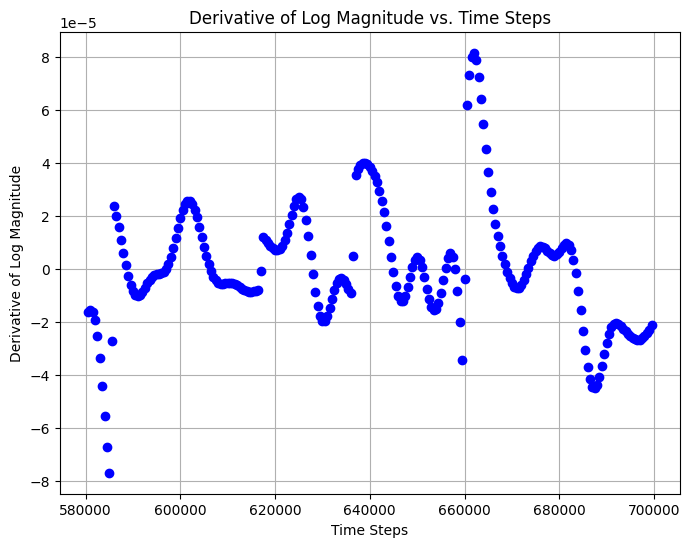

In [ ]:
#plot derivative of log(magnitude) vs time steps
print(len(list_time_steps))
def plot_derivative(rho_slice):
    for i in range (1,2000):
        derivative_log = (log_magnitude[i] - log_magnitude[i-1]) / (list_time_steps[i] - list_time_steps[i-1])
        derivative = (list_magnitude[i] - list_magnitude[i-1]) / (list_time_steps[i] - list_time_steps[i-1])

        plt.plot(list_time_steps[i], derivative_log, 'o',color='blue')
        plt.xlabel('Time Steps')
        plt.ylabel('Derivative of Log Magnitude')
        plt.title('Derivative of Log Magnitude vs. Time Steps')
        plt.grid(True)
        #plt.plot(list_time_steps[i], derivative, 'o',color='blue')

def plot_derivative_normal(rho_slice):
    for i in range (1,2000):
        derivative = (list_magnitude[i] - list_magnitude[i-1]) / (list_time_steps[i] - list_time_steps[i-1])
        plt.plot(list_time_steps[i], derivative, 'o',color='red')
        plt.xlabel('Time Steps')
        plt.ylabel('Derivative of Magnitude')
        plt.title('Derivative of Magnitude vs. Time Steps')
        plt.grid(True)

plt.figure(figsize=(8, 6))
plot_derivative(rho_slice)
plt.figure(figsize=(8, 6))
plot_derivative_normal(rho_slice)

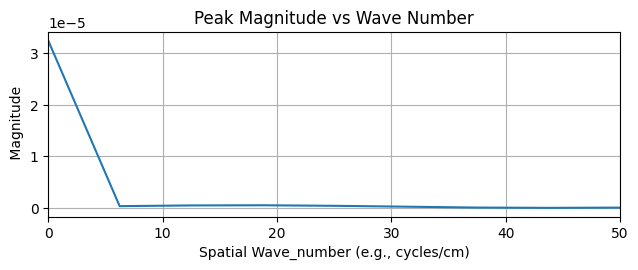

(np.float64(18.75577703635697), np.float64(5.634991139975339e-07))


In [ ]:
#plot FFT at a specific time step for a particular slice
file_save_at_time_i = load_data[f"time_step_{450000}"]

rho_at_i = file_save_at_time_i[0]
phi_at_i = file_save_at_time_i[1]
rho_slice = rho_at_i[100,:]
plt.subplot(2, 1, 2)
plt.yscale('linear') # Set the y-axis to a logarithmic scale
plt.plot(fft_rho_slice(rho_slice)[0], fft_rho_slice(rho_slice)[1])
plt.title('Peak Magnitude vs Wave Number')
plt.xlabel('Spatial Wave_number (e.g., cycles/cm)')
plt.ylabel(' Magnitude')
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 50)
plt.show()  
print(find_peaks(rho_slice))